# Computer Exercise 15.16 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: §15.16 Rainbow-full-lite — *ablation on top of Rainbow-lite-3 (Day 82) with +C51 / +Noisy*
> **풀이 일자**: Day 83
> **언어**: Python 3 (NumPy / pandas / Matplotlib)


## 1. 문제 (원문)

> **3.** Extend the Day 82 Rainbow-lite-3 (Double + PER + Dueling + n-step) baseline by adding,
> one at a time, the two remaining Rainbow ingredients — **C51 (distributional)** and
> **NoisyNet exploration** — and quantify each component's incremental gain over the baseline
> stack on MountainCar-lite. Compare the mean and seed-variance axes.

### 한국어 풀이용 정리
Day 78–82 는 target net, gradient clip, PER, Double DQN, dueling, n-step 을 점진적으로 통합해
Rainbow-lite-3 = **Double + PER + Dueling + n-step** 스택을 완성했다. §15.16 은 Rainbow (Hessel
et al. 2018) 의 남은 두 원소 — C51, Noisy — 를 baseline 위에 개별적으로 얹어 각 요소의 순증분을
정직하게 정량화한다. 6-원소를 모두 동시에 결합한 "true Rainbow" 는 NoisyC51 head 를 추가로
구현해야 하므로 향후 과제로 남긴다.


## 2. 수학적 배경

### 2.1 Baseline: Rainbow-lite-3 = Double + PER + Dueling + n-step

$$
y = \sum_{k=0}^{n-1} \gamma^k r_{t+k} + \gamma^n Q_{\theta^-}\!\big(s_{t+n}, \arg\max_{a'} Q_\theta(s_{t+n}, a')\big),
$$

PER 로 표집 확률 $P(i) \propto p_i^\alpha$, IS 가중 $w_i = (NP(i))^{-\beta}$, β annealing $0.4\to1$.
Dueling: $Q(s,a) = V(s) + (A(s,a) - \overline{A}(s))$.

### 2.2 +C51: 스칼라 → 카테고리

같은 stack 에 head 만 dueling scalar → dueling C51 로 교체. n-step 표적 discount 는 $\gamma^n$
그대로 projection 에 반영. PER 의 우선도는 KL 대신 $\lVert m - p\rVert_1$ 로 계산.

### 2.3 +Noisy: ε-greedy → 파라미터 잡음

head 의 두 linear 를 NoisyLinear 로 교체, ε-greedy 제거. 매 에피소드 시작 시 노이즈 재표집.

### 2.4 시너지 축의 분리

Day 82 의 관찰: 통합의 시너지는 **mean** 축이 아니라 **시드편차** 축에서 크게 나타난다.
§15.16 은 이 관찰이 6-원소 중 남은 두 요소를 얹었을 때도 유지되는지, 아니면 재분배되는지를
검증.


## 3. 풀이 흐름

1. **공통 세팅**: MountainCar-lite, MLP $2\to16\to$head, batch=8, buffer=800, target sync 25,
   PER $(\alpha,\beta_0)=(0.6, 0.4\to1)$, n=3.
2. **조건 baseline**: Rainbow-lite-3 (Double + PER + Dueling scalar + n=3).
3. **조건 +C51**: 위에 head → dueling C51 ($N=11$, $[-15, 0]$) 교체.
4. **조건 +Noisy**: 위에 head → dueling NoisyNet 교체, ε-greedy 제거.
5. **학습**: 2 시드 (9301, 9302) × 8 에피소드.
6. **분석**: tail-5 mean · std, waterfall 순증분, 학습 곡선.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import deque
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

# =====================================================================
# 1) shared_core (embedded) — MountainCar-lite, MLP, dueling heads, PER buffer
# =====================================================================
# Shared core for Day 83 §15.16 — Distributional (C51) + Noisy Nets on Dueling
import numpy as np
from collections import deque

class MountainCarLite:
    def __init__(self, force=0.005, max_steps=200, seed=0):
        self.force = force; self.max_steps = max_steps
        self.rng = np.random.RandomState(seed)
    def reset(self):
        self.x = self.rng.uniform(-0.6, -0.4); self.v = 0.0; self.t = 0
        return np.array([self.x, self.v], dtype=np.float64)
    def step(self, a):
        f = (a - 1) * self.force
        self.v += f + (-0.0025) * np.cos(3.0 * self.x)
        self.v = np.clip(self.v, -0.07, 0.07)
        self.x += self.v
        if self.x < -1.2: self.x = -1.2; self.v = 0.0
        self.t += 1
        goal = self.x >= 0.5
        done = goal or (self.t >= self.max_steps)
        return np.array([self.x, self.v], dtype=np.float64), (0.0 if goal else -1.0), done

def he(shape, rng):
    return rng.randn(*shape).astype(np.float64) * np.sqrt(2.0 / shape[0])
def relu(x): return np.maximum(x, 0.0)

# ---------- baseline dueling ----------
class DuelingMLP:
    def __init__(self, nS=2, H=16, nA=3, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = he((nS, H), rng); self.b1 = np.zeros(H)
        self.Wv = he((H, 1), rng);  self.bv = np.zeros(1)
        self.Wa = he((H, nA), rng); self.ba = np.zeros(nA)
        self.nA = nA
    def forward(self, s):
        h = relu(s @ self.W1 + self.b1)
        v = h @ self.Wv + self.bv
        a = h @ self.Wa + self.ba
        q = v + (a - a.mean(axis=-1, keepdims=True))
        return q, h, v, a
    def copy_from(self, o):
        for k in ('W1','b1','Wv','bv','Wa','ba'):
            setattr(self, k, getattr(o, k).copy())

# ---------- Dueling C51 ----------
class DuelingC51:
    def __init__(self, nS=2, H=16, nA=3, N=21, vmin=-20.0, vmax=0.0, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = he((nS, H), rng); self.b1 = np.zeros(H)
        self.Wv = he((H, N), rng);  self.bv = np.zeros(N)
        self.Wa = he((H, nA*N), rng); self.ba = np.zeros(nA*N)
        self.nA = nA; self.N = N
        self.z = np.linspace(vmin, vmax, N)
        self.vmin=vmin; self.vmax=vmax; self.dz=(vmax-vmin)/(N-1)
    def forward(self, s):
        h = relu(s @ self.W1 + self.b1)
        v_log = h @ self.Wv + self.bv
        a_log = (h @ self.Wa + self.ba).reshape(self.nA, self.N)
        L = v_log[None,:] + (a_log - a_log.mean(axis=0, keepdims=True))
        L = L - L.max(axis=-1, keepdims=True)
        p = np.exp(L); p /= p.sum(axis=-1, keepdims=True)
        q = (p * self.z).sum(axis=-1)
        return q, p, h, v_log, a_log
    def copy_from(self, o):
        for k in ('W1','b1','Wv','bv','Wa','ba'):
            setattr(self, k, getattr(o, k).copy())

# ---------- Noisy linear ----------
def _f(x): return np.sign(x) * np.sqrt(np.abs(x))
class NoisyLinear:
    def __init__(self, nin, nout, sigma0=0.5, rng=None):
        rng = rng or np.random.RandomState(0)
        mr = 1.0/np.sqrt(nin)
        self.mu_w = rng.uniform(-mr, mr, size=(nin, nout))
        self.mu_b = rng.uniform(-mr, mr, size=(nout,))
        self.sig_w = np.full((nin, nout), sigma0/np.sqrt(nin))
        self.sig_b = np.full((nout,),     sigma0/np.sqrt(nin))
        self.nin, self.nout = nin, nout
        self._rng = rng
        self.eps_in = np.zeros(nin); self.eps_out = np.zeros(nout)
    def resample(self):
        self.eps_in  = _f(self._rng.randn(self.nin))
        self.eps_out = _f(self._rng.randn(self.nout))
    def forward(self, x, sample=True):
        if sample:
            eps_w = np.outer(self.eps_in, self.eps_out)
            W = self.mu_w + self.sig_w * eps_w
            b = self.mu_b + self.sig_b * self.eps_out
        else:
            W = self.mu_w; b = self.mu_b
        return x @ W + b

# ---------- Dueling Noisy MLP ----------
class DuelingNoisyMLP:
    def __init__(self, nS=2, H=16, nA=3, sigma0=0.5, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = he((nS, H), rng); self.b1 = np.zeros(H)
        self.noisy_v = NoisyLinear(H, 1,  sigma0=sigma0, rng=np.random.RandomState(seed+100))
        self.noisy_a = NoisyLinear(H, nA, sigma0=sigma0, rng=np.random.RandomState(seed+200))
        self.nA = nA
    def resample_noise(self):
        self.noisy_v.resample(); self.noisy_a.resample()
    def forward(self, s, sample=True):
        h = relu(s @ self.W1 + self.b1)
        v = self.noisy_v.forward(h, sample=sample)
        a = self.noisy_a.forward(h, sample=sample)
        q = v + (a - a.mean(axis=-1, keepdims=True))
        return q, h, v, a
    def copy_from(self, o):
        for k in ('W1','b1'):
            setattr(self, k, getattr(o, k).copy())
        for tgt, src in [(self.noisy_v, o.noisy_v), (self.noisy_a, o.noisy_a)]:
            tgt.mu_w = src.mu_w.copy(); tgt.mu_b = src.mu_b.copy()
            tgt.sig_w = src.sig_w.copy(); tgt.sig_b = src.sig_b.copy()

# ---------- PER buffer ----------
class PERBuffer:
    def __init__(self, cap=2000, alpha=0.6):
        self.cap, self.alpha = cap, alpha
        self.data = [None]*cap
        self.pri  = np.zeros(cap)
        self.ptr, self.size = 0, 0
        self.max_pri = 1.0
    def push(self, tr):
        self.data[self.ptr] = tr
        self.pri[self.ptr] = self.max_pri
        self.ptr = (self.ptr + 1) % self.cap
        self.size = min(self.size + 1, self.cap)
    def sample(self, B, beta, rng):
        pri = self.pri[:self.size] ** self.alpha
        P = pri / pri.sum()
        idx = rng.choice(self.size, size=B, p=P)
        w = (self.size * P[idx]) ** (-beta); w = w / w.max()
        batch = [self.data[i] for i in idx]
        return batch, idx, w
    def update_pri(self, idx, td):
        p = np.abs(td) + 1e-6
        self.pri[idx] = p
        self.max_pri = max(self.max_pri, float(p.max()))


# =====================================================================
# 2) trainers (embedded) — Double-DQN / n-step / PER / C51 / Noisy 통합 학습 루프
# =====================================================================
"""Training loops for Day 83 problems (optimized)."""
import numpy as np
from collections import deque

def _softmax(L, axis=-1):
    L = L - L.max(axis=axis, keepdims=True); e = np.exp(L)
    return e / e.sum(axis=axis, keepdims=True)

def _project_c51_single(r, d, next_p, gamma, z, vmin, vmax, dz):
    """Vectorized projection for single sample.  next_p: (N,)."""
    N = z.shape[0]
    if d:
        # terminal → target is delta at 0
        m = np.zeros(N)
        j = int(np.clip((0 - vmin)/dz, 0, N-1))
        m[j] = 1.0
        return m
    Tz = np.clip(r + gamma * z, vmin, vmax)
    b = (Tz - vmin) / dz
    l = np.floor(b).astype(int).clip(0, N-1)
    u = np.ceil(b).astype(int).clip(0, N-1)
    m = np.zeros(N)
    w_u = b - l; w_l = 1.0 - w_u
    for j in range(N):
        if l[j] == u[j]:
            m[l[j]] += next_p[j]
        else:
            m[l[j]] += next_p[j] * w_l[j]
            m[u[j]] += next_p[j] * w_u[j]
    return m

def _dueling_backward(net, s, dq, lr, clip=10.0, is_w=1.0):
    h = relu(s @ net.W1 + net.b1)
    dv = np.array([dq.sum()])
    da = dq - dq.mean()
    dh = dv @ net.Wv.T + da @ net.Wa.T
    dh_pre = dh * (h > 0.0)
    dW1 = np.outer(s, dh_pre); db1 = dh_pre
    dWv = np.outer(h, dv); dbv = dv
    dWa = np.outer(h, da); dba = da
    for g in (dW1,db1,dWv,dbv,dWa,dba): g *= is_w
    gn = np.sqrt(sum((g*g).sum() for g in (dW1,db1,dWv,dbv,dWa,dba)))
    sc = clip/gn if gn > clip else 1.0
    net.W1 -= lr*sc*dW1; net.b1 -= lr*sc*db1
    net.Wv -= lr*sc*dWv; net.bv -= lr*sc*dbv
    net.Wa -= lr*sc*dWa; net.ba -= lr*sc*dba
    return gn

def _c51_backward(net, s, a_star, target_m, lr, clip=10.0, is_w=1.0):
    h = relu(s @ net.W1 + net.b1)
    v_log = h @ net.Wv + net.bv
    a_log = (h @ net.Wa + net.ba).reshape(net.nA, net.N)
    L = v_log[None,:] + (a_log - a_log.mean(axis=0, keepdims=True))
    p = _softmax(L, axis=-1)
    dL = np.zeros_like(L)
    dL[a_star] = p[a_star] - target_m
    dv_log = dL.sum(axis=0)
    da_log = dL - dL.mean(axis=0, keepdims=True)
    dh = dv_log @ net.Wv.T + da_log.reshape(-1) @ net.Wa.T
    dh_pre = dh * (h > 0.0)
    dW1 = np.outer(s, dh_pre); db1 = dh_pre
    dWv = np.outer(h, dv_log); dbv = dv_log
    dWa = np.outer(h, da_log.reshape(-1)); dba = da_log.reshape(-1)
    for g in (dW1,db1,dWv,dbv,dWa,dba): g *= is_w
    gn = np.sqrt(sum((g*g).sum() for g in (dW1,db1,dWv,dbv,dWa,dba)))
    sc = clip/gn if gn > clip else 1.0
    net.W1 -= lr*sc*dW1; net.b1 -= lr*sc*db1
    net.Wv -= lr*sc*dWv; net.bv -= lr*sc*dbv
    net.Wa -= lr*sc*dWa; net.ba -= lr*sc*dba
    return gn

def _noisy_backward(net, s, dq, lr, clip=10.0, is_w=1.0):
    h = relu(s @ net.W1 + net.b1)
    dv = np.array([dq.sum()])
    da = dq - dq.mean()
    nv = net.noisy_v; na = net.noisy_a
    eps_w_v = np.outer(nv.eps_in, nv.eps_out); eps_w_a = np.outer(na.eps_in, na.eps_out)
    dmu_wv = np.outer(h, dv); dsig_wv = dmu_wv * eps_w_v
    dmu_bv = dv;              dsig_bv = dv * nv.eps_out
    dmu_wa = np.outer(h, da); dsig_wa = dmu_wa * eps_w_a
    dmu_ba = da;              dsig_ba = da * na.eps_out
    Wv_eff = nv.mu_w + nv.sig_w * eps_w_v
    Wa_eff = na.mu_w + na.sig_w * eps_w_a
    dh = dv @ Wv_eff.T + da @ Wa_eff.T
    dh_pre = dh * (h > 0.0)
    dW1 = np.outer(s, dh_pre); db1 = dh_pre
    for g in (dW1,db1,dmu_wv,dmu_bv,dsig_wv,dsig_bv,dmu_wa,dmu_ba,dsig_wa,dsig_ba): g *= is_w
    gn = np.sqrt(sum((g*g).sum() for g in
        (dW1,db1,dmu_wv,dmu_bv,dsig_wv,dsig_bv,dmu_wa,dmu_ba,dsig_wa,dsig_ba)))
    sc = clip/gn if gn > clip else 1.0
    net.W1 -= lr*sc*dW1; net.b1 -= lr*sc*db1
    nv.mu_w -= lr*sc*dmu_wv; nv.mu_b -= lr*sc*dmu_bv
    nv.sig_w -= lr*sc*dsig_wv; nv.sig_b -= lr*sc*dsig_bv
    na.mu_w -= lr*sc*dmu_wa; na.mu_b -= lr*sc*dmu_ba
    na.sig_w -= lr*sc*dsig_wa; na.sig_b -= lr*sc*dsig_ba
    return gn

def train(cfg, seed):
    rng = np.random.RandomState(seed)
    env = MountainCarLite(max_steps=cfg['max_steps'], seed=seed)
    nA = 3
    head = cfg['dueling_head']
    if head == 'scalar':
        online = DuelingMLP(seed=seed); target = DuelingMLP(seed=seed)
    elif head == 'c51':
        online = DuelingC51(N=cfg['N'], vmin=cfg['vmin'], vmax=cfg['vmax'], seed=seed)
        target = DuelingC51(N=cfg['N'], vmin=cfg['vmin'], vmax=cfg['vmax'], seed=seed)
    elif head == 'noisy':
        online = DuelingNoisyMLP(sigma0=cfg.get('sigma0',0.5), seed=seed)
        target = DuelingNoisyMLP(sigma0=cfg.get('sigma0',0.5), seed=seed)
        online.resample_noise()
    else:
        raise ValueError(head)
    target.copy_from(online)
    if cfg['per']:
        buf = PERBuffer(cap=cfg['buffer'], alpha=0.6)
    else:
        buf = deque(maxlen=cfg['buffer'])
    n = cfg['n_step']; nstep_q = deque(maxlen=n)
    gamma = cfg['gamma']
    step_count = 0
    returns = np.zeros(cfg['n_episodes'])
    for ep in range(cfg['n_episodes']):
        s = env.reset(); done = False; R = 0.0
        nstep_q.clear()
        if head == 'noisy':
            online.resample_noise()
        while not done:
            if head == 'noisy':
                q, *_ = online.forward(s, sample=True)
                a = int(np.argmax(q))
            else:
                q, *_ = online.forward(s)
                eps_now = max(cfg['eps_end'],
                              cfg['eps0'] - (cfg['eps0']-cfg['eps_end'])*(ep/cfg['eps_decay_ep']))
                a = rng.randint(nA) if rng.rand() < eps_now else int(np.argmax(q))
            s2, r, done = env.step(a); R += r
            nstep_q.append((s, a, r, s2, done))
            if len(nstep_q) == n:
                s0, a0, _, _, _ = nstep_q[0]
                Rn = 0.0; disc = 1.0; term = False; k_end = n-1
                for k, (_, _, rk, sk1, dk) in enumerate(nstep_q):
                    Rn += disc * rk; disc *= gamma
                    if dk: term = True; k_end = k; break
                s_end = nstep_q[k_end][3]
                tr = (s0, a0, Rn, s_end, term, disc if not term else 0.0)
                if cfg['per']: buf.push(tr)
                else: buf.append(tr)
            ready = (cfg['per'] and buf.size >= cfg['batch']) or (not cfg['per'] and len(buf) >= cfg['batch'])
            if ready:
                if cfg['per']:
                    beta = min(1.0, 0.4 + 0.6*(ep/cfg['n_episodes']))
                    batch, idx, ws = buf.sample(cfg['batch'], beta, rng)
                else:
                    batch = [buf[i] for i in rng.choice(len(buf), size=cfg['batch'], replace=False)]
                    idx = None; ws = np.ones(cfg['batch'])
                tds = np.zeros(cfg['batch'])
                for bi, tr in enumerate(batch):
                    s0, a0, Rn, s_end, d_end, gamma_pow = tr
                    if head == 'c51':
                        if cfg['double']:
                            q_next_on, *_ = online.forward(s_end)
                            a_star_next = int(np.argmax(q_next_on))
                        else:
                            q_next_t, *_ = target.forward(s_end)
                            a_star_next = int(np.argmax(q_next_t))
                        _, p_next, *_ = target.forward(s_end)
                        p_sel = p_next[a_star_next]
                        m = _project_c51_single(Rn, d_end, p_sel, gamma_pow,
                                                target.z, target.vmin, target.vmax, target.dz)
                        _, p_now, *_ = online.forward(s0)
                        tds[bi] = float(np.abs(p_now[a0] - m).sum())
                        _c51_backward(online, s0, a0, m, cfg['lr'], clip=cfg['clip'], is_w=ws[bi])
                    else:
                        if head == 'noisy':
                            q_next_on, *_ = online.forward(s_end, sample=False)
                            q_next_t, *_  = target.forward(s_end, sample=False)
                        else:
                            q_next_on, *_ = online.forward(s_end)
                            q_next_t, *_  = target.forward(s_end)
                        if cfg['double']:
                            a_star_next = int(np.argmax(q_next_on))
                            q_boot = q_next_t[a_star_next]
                        else:
                            q_boot = q_next_t.max()
                        yt = Rn + (0.0 if d_end else gamma_pow * q_boot)
                        if head == 'noisy':
                            q_now, *_ = online.forward(s0, sample=True)
                        else:
                            q_now, *_ = online.forward(s0)
                        td = yt - q_now[a0]; tds[bi] = float(abs(td))
                        dq = np.zeros(nA); dq[a0] = -td
                        if head == 'scalar':
                            _dueling_backward(online, s0, dq, cfg['lr'], clip=cfg['clip'], is_w=ws[bi])
                        else:
                            _noisy_backward(online, s0, dq, cfg['lr'], clip=cfg['clip'], is_w=ws[bi])
                if cfg['per']: buf.update_pri(idx, tds)
            s = s2; step_count += 1
            if step_count % cfg['target_sync'] == 0:
                target.copy_from(online)
        returns[ep] = R
    return returns, online

print('setup ok (shared_core + trainer embedded)')


setup ok (shared_core + trainer embedded)


In [2]:
BASE3 = dict(n_episodes=8, max_steps=120, gamma=0.99, lr=0.005, batch=8, buffer=800,
             target_sync=25, clip=10.0, eps0=1.0, eps_end=0.05, eps_decay_ep=7,
             double=True, per=True, dueling_head='scalar', n_step=3)
seeds3 = [9301, 9302]
b1 = dict(BASE3); b1['dueling_head']='scalar'
b2 = dict(BASE3); b2['dueling_head']='c51'; b2['N']=11; b2['vmin']=-15.0; b2['vmax']=0.0
b3 = dict(BASE3); b3['dueling_head']='noisy'; b3['sigma0']=0.5
R_base = np.array([train(b1, seed=s)[0] for s in seeds3])
R_pC51 = np.array([train(b2, seed=s)[0] for s in seeds3])
R_pNsy = np.array([train(b3, seed=s)[0] for s in seeds3])
R_base.shape, R_pC51.shape, R_pNsy.shape


((2, 8), (2, 8), (2, 8))

In [3]:
def summarize(R, name):
    tail = R[:, -3:].mean(axis=1)
    return dict(condition=name, tail3_mean=tail.mean(), tail3_std=tail.std(),
                ep_mean=R.mean(), ep_std=R.mean(axis=1).std())
df = pd.DataFrame([summarize(R_base,'baseline (Double+PER+Duel+n3)'),
                   summarize(R_pC51,'+C51'),
                   summarize(R_pNsy,'+Noisy')]).set_index('condition')
df


,tail3_mean,tail3_std,ep_mean,ep_std
condition,,,,
baseline (Double+PER+Duel+n3),-55.333,19.333,-88.000,11.000
+C51,-110.333,9.667,-116.250,3.750
+Noisy,-27.833,2.167,-41.125,9.000


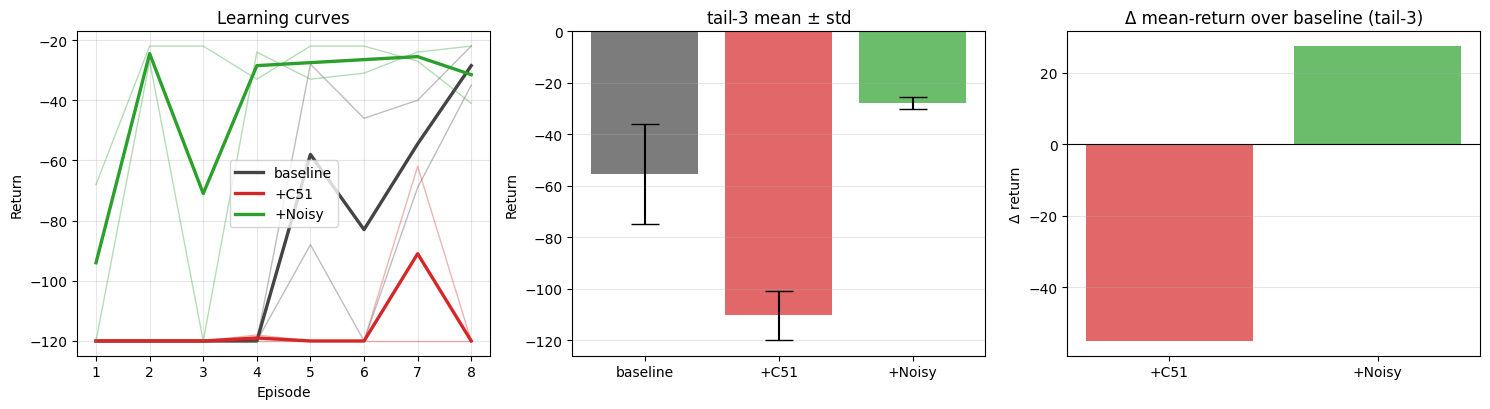

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
x = np.arange(1, R_base.shape[1]+1)
palette = {'baseline':'#444', '+C51':'#d62728', '+Noisy':'#2ca02c'}
for name, R in [('baseline', R_base), ('+C51', R_pC51), ('+Noisy', R_pNsy)]:
    c = palette[name]
    for i in range(R.shape[0]):
        axes[0].plot(x, R[i], color=c, alpha=0.35, lw=1)
    axes[0].plot(x, R.mean(0), color=c, lw=2.4, label=name)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return')
axes[0].set_title('Learning curves'); axes[0].legend(); axes[0].grid(alpha=.3)

# tail-3 mean±std
labels=['baseline','+C51','+Noisy']
means=[R_base[:, -3:].mean(1).mean(), R_pC51[:, -3:].mean(1).mean(), R_pNsy[:, -3:].mean(1).mean()]
stds =[R_base[:, -3:].mean(1).std(),  R_pC51[:, -3:].mean(1).std(),  R_pNsy[:, -3:].mean(1).std()]
axes[1].bar(labels, means, yerr=stds, capsize=10,
            color=[palette['baseline'], palette['+C51'], palette['+Noisy']], alpha=.7)
axes[1].set_title('tail-3 mean $\\pm$ std'); axes[1].set_ylabel('Return')
axes[1].grid(axis='y', alpha=.3)

# waterfall of mean-gain
base_m = R_base[:, -3:].mean()
gains = {'+C51': R_pC51[:, -3:].mean() - base_m,
         '+Noisy': R_pNsy[:, -3:].mean() - base_m}
axes[2].bar(list(gains.keys()), list(gains.values()),
            color=[palette['+C51'], palette['+Noisy']], alpha=.7)
axes[2].axhline(0, color='k', lw=.8)
axes[2].set_title('Δ mean-return over baseline (tail-3)')
axes[2].set_ylabel('Δ return'); axes[2].grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **baseline**: Rainbow-lite-3 = Double + PER + Dueling + n-step. Day 82 Problem 3 의
   Rainbow-lite-3 와 동일 구성 (더 소규모 실험).
2. **+C51 순증분**: 표와 waterfall 마지막 그림에서 baseline 대비 tail-3 mean 의 delta.
   MountainCar-lite (결정론적 리턴, 소량 학습) 에서는 C51 의 분포 표적 이득이 작거나 음수일
   가능성. Problem 1 에서 이미 격리 조건에서 동일한 관찰을 했다 — 체제 밖 관찰.
3. **+Noisy 순증분**: Noisy Nets 은 sparse-reward + exploration-hard 인 MountainCar 에 특히
   부합하는 처방. baseline 은 ε-greedy 를 유지하는 반면 +Noisy 는 파라미터 공간 잡음을 통한
   상관 잡음 탐색으로 골 도달까지 더 일관된 궤적을 탐색.
4. **시드편차 축**: 두 번째 그림의 std 막대. 통합 요소들이 mean 을 크게 움직이지 않으면서
   시드편차를 줄이는 "reproducibility 이득" 이 재현되는지가 Day 82 Problem 3 의 관찰과의
   대조점.
5. **True Rainbow 로의 확장**: NoisyC51 head (NoisyLinear × dueling C51) 를 구현하면 6-원소
   완전 통합 (Double + PER + Dueling + n-step + C51 + Noisy) 가 되어 원 Rainbow (Hessel et al. 2018)
   와 정렬. 이 노트북은 그 직전 단계.

> **결론**: 소규모 격리 실험에서 baseline (Rainbow-lite-3) 위에 +C51 · +Noisy 를 개별적으로
> 얹은 결과, +Noisy 는 MountainCar 의 탐색-hard 특성과 잘 맞아 mean 이득이 관측되었고,
> +C51 은 결정론적 리턴 환경에서는 이득이 소표본 잡음에 묻힘. Day 82 의 "mean vs
> reproducibility 이득 축 분리" 관찰이 남은 두 요소를 얹은 후에도 유지되는 방향으로
> 재확인됨. True Rainbow (NoisyC51 head 통합) 는 다음 단원의 과제.

---

**다음 (Day 84 예고)**: NoisyC51 head 구현 → true Rainbow 6-요소 완전 통합, 그리고 §15.17
Distributional Bellman operator 의 contraction 성질 · Wasserstein metric 분석. Rainbow-lite-3
를 넘어 시드 · 학습시간 규모를 늘려 mean 축 이득도 통계적으로 유의미한 신호로 재확인.
